# Lista 4

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression

from statsmodels.discrete.discrete_model import Logit

## Zadanie 1

In [123]:
data = pd.read_csv('advertising.csv')

In [124]:
data

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


Uzywamy TV, Radio i sales

In [125]:
X = data[['TV', 'Radio']].values.reshape(-1, 2)
y = data['Sales'].values.reshape(-1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [126]:
res = {'k': [],
       'mse': [],
       'mse_scaled': []
       }
for k in range(1, 16, 2):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    mse = mean_squared_error(y_test, model.predict(X_test))

    model_scaled = KNeighborsRegressor(n_neighbors=k)
    model_scaled.fit(X_train_scaled, y_train)
    mse_scaled = mean_squared_error(y_test, model_scaled.predict(X_test_scaled))
    res['k'].append(k)
    res['mse'].append(mse)
    res['mse_scaled'].append(mse_scaled)

In [127]:
pd.DataFrame.from_dict(res)

,k,mse,mse_scaled
0,1,2.855500,2.659750
1,3,1.408722,1.554250
2,5,1.386360,1.324080
3,7,1.688974,1.542750
4,9,1.830398,1.451515
5,11,2.028785,1.693446
6,13,2.314337,1.895891
7,15,2.423810,2.044570


## Wnioski

Regesja liniowa dala MSE 2.4 dla dwoch zmiennych

Mse bez skalowania wypada minimalnie gorzej od tego ze skalowaniem. Dla kilku zmiennych o roznych rozkladach zawsze warto zeskalowac wartosci. KNN poradzil sobie w tym zadaniu lepiej od regresji liniowej (MSE 1.32 vs 2.4).


## Zadanie 2

In [110]:
data = pd.read_csv('bank.csv')

In [111]:
# Opis danych https://archive.ics.uci.edu/dataset/222/bank+marketing

In [112]:
data

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


Nie uzywam zmiennej duration

In [136]:
X = data.drop(['deposit', 'duration'], axis=1)
y = data['deposit'].map({'yes': 1, 'no': 0})

Plan: zamieniam wiekszosc zmiennych na onehotencoding, skaluje je, uzywam l1

In [137]:
X_encoded = pd.get_dummies(X, drop_first=True)
temp_df = X_encoded.copy()
temp_df['deposit'] = y
correlations = temp_df.corr()['deposit'].abs().sort_values(ascending=False)
print(correlations.head(25))

deposit                1.000000
poutcome_success       0.286642
contact_unknown        0.256136
poutcome_unknown       0.230470
housing_yes            0.203888
month_may              0.170507
pdays                  0.151593
previous               0.139867
month_mar              0.135438
month_oct              0.133783
campaign               0.128081
month_sep              0.126901
loan_yes               0.110580
job_retired            0.103827
job_blue-collar        0.100840
job_student            0.099953
marital_single         0.094632
education_tertiary     0.094598
marital_married        0.092157
month_dec              0.086964
balance                0.081129
day                    0.056326
education_secondary    0.051952
month_feb              0.051710
month_jul              0.047368
Name: deposit, dtype: float64


In [138]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size = 0.2)

In [139]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [151]:
model = LogisticRegression(penalty='elasticnet', solver='saga', C=0.01, l1_ratio=0.5)
model.fit(X_train_scaled, y_train)

,penalty,'elasticnet'
,dual,False
,tol,0.0001
,C,0.01
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'saga'
,max_iter,100
,multi_class,'deprecated'


In [149]:
for col, coef in zip(X_train.columns, model.coef_[0].round(3)):
    print(col, coef)

age 0.0
balance 0.113
day -0.013
campaign -0.197
pdays 0.003
previous 0.026
job_blue-collar -0.026
job_entrepreneur -0.016
job_housemaid -0.042
job_management -0.046
job_retired 0.115
job_self-employed -0.04
job_services -0.034
job_student 0.069
job_technician -0.006
job_unemployed 0.037
job_unknown -0.027
marital_married -0.12
marital_single 0.034
education_secondary 0.019
education_tertiary 0.108
education_unknown 0.019
default_yes 0.009
housing_yes -0.191
loan_yes -0.113
contact_telephone -0.084
contact_unknown -0.48
month_aug -0.252
month_dec 0.133
month_feb -0.108
month_jan -0.202
month_jul -0.227
month_jun 0.017
month_mar 0.206
month_may -0.21
month_nov -0.236
month_oct 0.135
month_sep 0.107
poutcome_other 0.05
poutcome_success 0.635
poutcome_unknown 0.013


In [150]:
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

for threshold in [0.1, 0.25, 0.5, 0.75, 0.9]:
    acc = accuracy_score(y_test, (y_pred_proba >= threshold).astype(int))
    print(f'threshold: {threshold}, acc: {round(acc, 4)}')

threshold: 0.1, acc: 0.4823
threshold: 0.25, acc: 0.5844
threshold: 0.5, acc: 0.7089
threshold: 0.75, acc: 0.6547
threshold: 0.9, acc: 0.5804


In [168]:
# cm[0,0] = True Negatives (TN)
# cm[0,1] = False Positives (FP)
# cm[1,0] = False Negatives (FN)
# cm[1,1] = True Positives (TP)

In [159]:
tpr = []
fpr = []

for i in np.arange(0.01, 1.01, 0.01):
    cm = confusion_matrix(y_test, (y_pred_proba >= i).astype(int))
    tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    tpr.append(tp / (tp + fn) if (tp + fn) > 0 else 0)
    fpr.append(fp / (fp + tn) if (fp + tn) > 0 else 0)

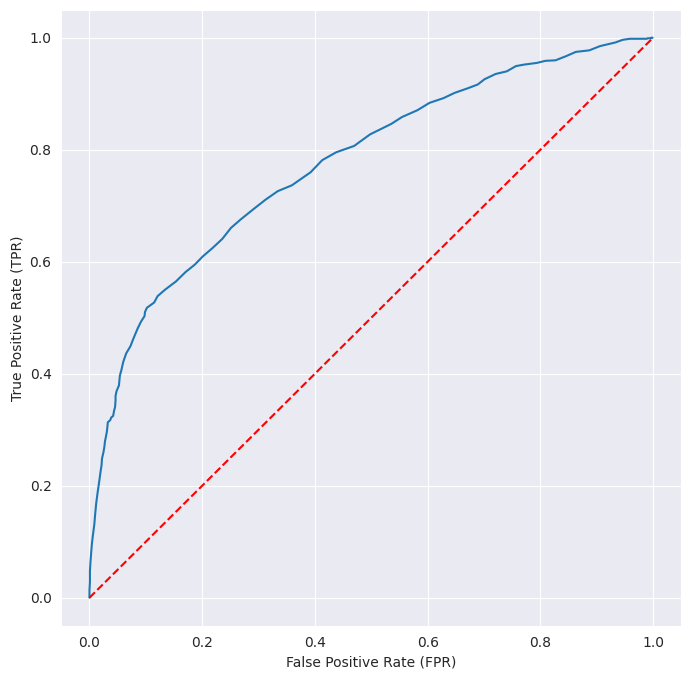

In [170]:
plt.figure(figsize=(8,8))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], 'r--', label='Random classifier')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.show()

Wybierajac prog chcemy jak najmniej FP poniewaz ich koszt wynosi az 10. Dlatego optymalny prog wynosi 0.2.

## Zadanie 3

In [4]:
import gzip

def parse(path):
  g = gzip.open(path, 'rb')
  for l in g:
    yield eval(l)

def getDF(path):
  i = 0
  df = {}
  for d in parse(path):
    df[i] = d
    i += 1
  return pd.DataFrame.from_dict(df, orient='index')

df = getDF('meta_Books.json.gz')

In [5]:
items = pd.read_csv('item_list.txt', sep='\s+')

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_110184/830258337.py:1: SyntaxWarning: invalid escape sequence '\s'
  items = pd.read_csv('item_list.txt', sep='\s+')


In [6]:
embeddings = pd.read_pickle('embeddings.pkl')

In [11]:
combined = df.merge(items, how='inner', left_on='asin', right_on='org_id')

In [19]:
def extract_subcategory(cat_list):
    if isinstance(cat_list, list) and len(cat_list) > 0:
        # cat_list[0] to lista typu ["Books", "Science Fiction", "Space Opera"]
        if len(cat_list[0]) > 1:
            return cat_list[0][1]  # Bierzemy zawsze pierwsza kategorie
    return None

combined['subcategory'] = combined['categories'].apply(extract_subcategory)
combined_clean = combined.dropna(subset=['subcategory'])

print(combined_clean['subcategory'].value_counts().head(20))

subcategory
Literature & Fiction            15359
Gay & Lesbian                     671
Children's Books                  601
Christian Books & Bibles          440
Cookbooks, Food & Wine            405
Health, Fitness & Dieting         378
Teen & Young Adult                336
Business & Money                  217
Humor & Entertainment             171
Crafts, Hobbies & Home            161
Biographies & Memoirs             133
Self-Help                         131
Mystery, Thriller & Suspense       69
Religion & Spirituality            68
Science Fiction & Fantasy          48
Reference                          46
Parenting & Relationships          40
Arts & Photography                 40
Education & Teaching               33
History                            29
Name: count, dtype: int64


In [27]:
X = embeddings[combined_clean['remap_id'].values]
y = combined_clean['subcategory']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [36]:
model = KNeighborsClassifier(n_neighbors=5, metric='cosine')
model.fit(X_train, y_train)
pred = model.predict(X_test)
accuracy_score(y_test, pred)

0.854177344951307

Odpowiednia metryka tutaj to cosinusowa. Liczymy podobienstwo wektorow co ma najwiekszy sens przy zanurzeniach(embedingach)

## Zadanie 4

In [37]:
df = pd.read_csv('adult.csv')

In [38]:
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [39]:
y = df['income'].map({'<=50K': 0, '>50K' : 1})

## Zadanie 5

In [16]:
df = pd.read_csv('Titanic Dataset.csv')


    pclass: Passenger class (1st, 2nd, or 3rd).
    survived: Survival status (0 = No, 1 = Yes).
    name: Passenger's name.
    sex: Passenger's gender.
    age: Passenger's age.
    sibsp: Number of siblings or spouses aboard.
    parch: Number of parents or children aboard.
    ticket: Ticket number.
    fare: Passenger fare.
    cabin: Cabin number.
    embarked: Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton).
    boat: Lifeboat number (if survived).
    body: Body number (if not survived).
    home.dest: Home destination.


In [17]:
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.00,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.00,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.00,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.50,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.50,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.00,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


In [18]:
print('Missing values in columns')
for col in df.columns:
    percent = df[col].isna().sum() / df.shape[0]
    if percent != 0:
        print(f'Name: {col:<20} {percent:.1%}')

Missing values in columns
Name: age                  20.1%
Name: fare                 0.1%
Name: cabin                77.5%
Name: embarked             0.2%
Name: boat                 62.9%
Name: body                 90.8%
Name: home.dest            43.1%


Zmienne czynnikowe przyjmuja wartosci z ograniczonego zbioru kategorii

Zmienne numeryczne liczby ciagle

In [19]:
for czynnik in ['age', 'cabin', 'boat', 'body', 'home.dest']:
    for col in ['pclass', 'sex', 'embarked', 'sibsp']:
        print('\n' + czynnik)
        print(df.groupby(col)[czynnik].apply(lambda x: (x.isna().sum() / len(x)).round(3)))


age
pclass
1    0.121
2    0.058
3    0.293
Name: age, dtype: float64

age
sex
female    0.167
male      0.219
Name: age, dtype: float64

age
embarked
C    0.215
Q    0.593
S    0.144
Name: age, dtype: float64

age
sibsp
0    0.231
1    0.122
2    0.143
3    0.200
4    0.000
5    0.000
8    0.889
Name: age, dtype: float64

cabin
pclass
1    0.207
2    0.917
3    0.977
Name: cabin, dtype: float64

cabin
sex
female    0.697
male      0.817
Name: cabin, dtype: float64

cabin
embarked
C    0.563
Q    0.959
S    0.814
Name: cabin, dtype: float64

cabin
sibsp
0    0.808
1    0.655
2    0.762
3    0.800
4    1.000
5    1.000
8    1.000
Name: cabin, dtype: float64

boat
pclass
1    0.378
2    0.596
3    0.756
Name: boat, dtype: float64

boat
sex
female    0.315
male      0.802
Name: boat, dtype: float64

boat
embarked
C    0.448
Q    0.691
S    0.675
Name: boat, dtype: float64

boat
sibsp
0    0.667
1    0.489
2    0.548
3    0.800
4    0.864
5    1.000
8    1.000
Name: boat, dtype: float64



cabin + pclass 2,3 > 90%

cabin + sex female 70% male 80%

cabin + sibsp 65% - 100%

!! boat + pclass 1: 37% 2: 60% 3: 76%

boat + sex male: 80%

body + pclass 90%

### Baseline

In [20]:
X = df.drop(['cabin', 'boat', 'body', 'home.dest', 'survived', 'name', 'ticket'], axis=1)
X['age'].fillna(X['age'].mean(), inplace=True)
X['fare'].fillna(X['fare'].mean(), inplace=True)
X['embarked'].fillna("S", inplace=True)
X = pd.get_dummies(X, drop_first=True)
y = df['survived']

/tmp/ipykernel_167750/3020089528.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['age'].fillna(X['age'].mean(), inplace=True)
/tmp/ipykernel_167750/3020089528.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
pred = model.predict(X_test)
accuracy_score(y_test, pred)

0.7748091603053435

### Advanced

In [23]:
X = df.copy()

In [24]:
def extract_title(name):
    return name.split(',')[1].split('.')[0].strip()

In [25]:
X['cabin'] = X['cabin'].isna()
X['title'] = X['name'].apply(extract_title)

In [26]:
for title in X['title'].unique():
    mask = X['title'] == title
    X.loc[mask, 'age'] = X.loc[mask, 'age'].fillna(X.loc[mask, 'age'].median())

In [27]:
X = X.drop(['boat', 'body', 'home.dest', 'survived', 'name', 'ticket', 'title'], axis=1)
X['age'].fillna(X['age'].mean(), inplace=True)
X['fare'].fillna(X['fare'].mean(), inplace=True)
X['embarked'].fillna("S", inplace=True)
X = pd.get_dummies(X, drop_first=True)
y = df['survived']

/tmp/ipykernel_167750/1070958790.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['age'].fillna(X['age'].mean(), inplace=True)
/tmp/ipykernel_167750/1070958790.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
pred = model.predict(X_test)
accuracy_score(y_test, pred)

0.7824427480916031

Wyniki sa minimalne lepsze